<a href="https://colab.research.google.com/github/kavithaBakka/CodeAlpha_CarPricePrediction/blob/main/Another_copy_of_CodeAlpha_CarPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CodeAlpha Internship
# Task 3 - Car Price Prediction
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data (3).csv


In [ ]:
df = pd.read_csv("car data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print("Shape:", df.shape)

df.info()

Shape: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = encoder.fit_transform(df[column])

print("Categorical columns converted successfully.")

Categorical columns converted successfully.


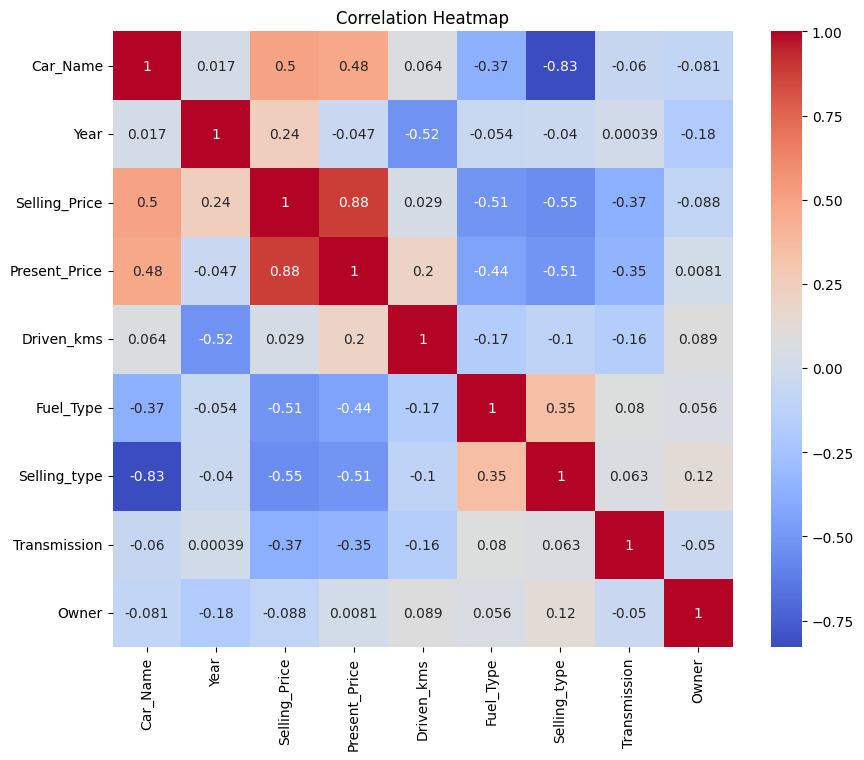

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (240, 8)
Testing Samples: (61, 8)


In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [ ]:
predictions = model.predict(X_test)

predictions[:10]

array([ 0.4433, 10.32  ,  5.01  ,  0.2094,  7.8531,  6.712 ,  1.1306,
        0.6118,  0.464 ,  6.641 ])

In [ ]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 0.589304918032787
Mean Squared Error : 0.782636952131147
Root Mean Squared Error : 0.884667707182277
R2 Score : 0.9660248711535068


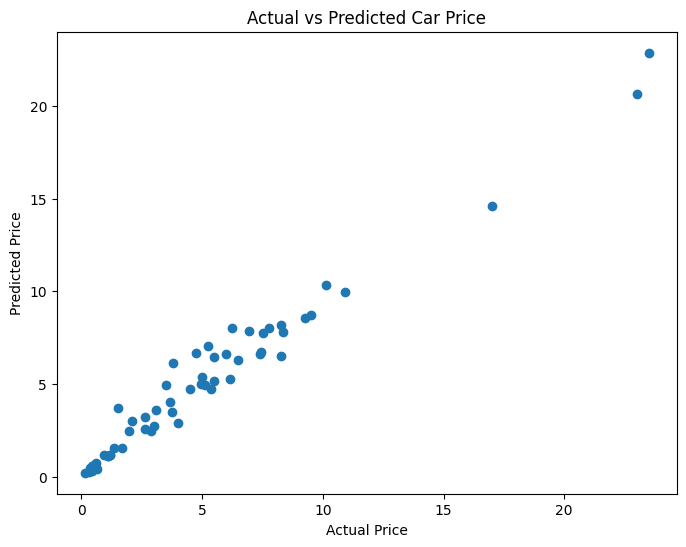

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Price")

plt.show()

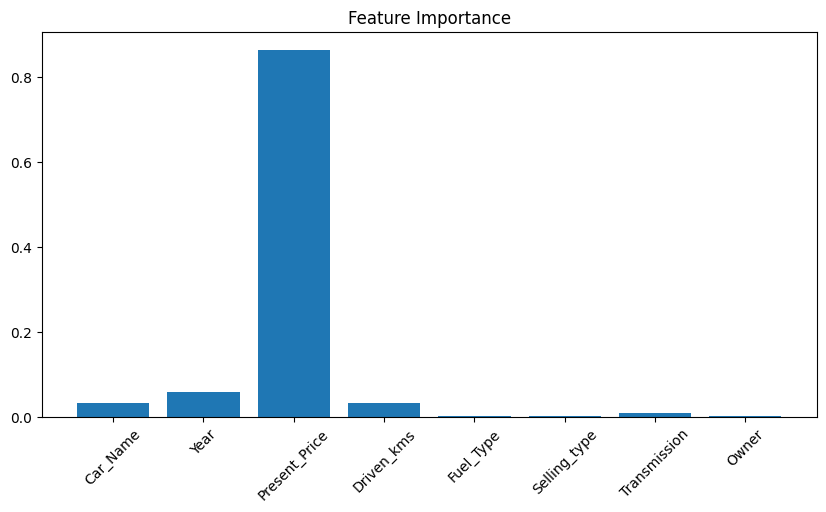

In [ ]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [ ]:
sample = X.iloc[[0]]

predicted_price = model.predict(sample)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 3.8885000000000036


In [ ]:
print("=====================================")

print("PROJECT COMPLETED SUCCESSFULLY")

print("Task : Car Price Prediction")

print("Machine Learning Model : Random Forest Regressor")

print("R2 Score :", round(r2,3))

print("RMSE :", round(rmse,3))

print()

print("Conclusion:")

print("- Dataset cleaned successfully.")

print("- Features were encoded and prepared.")

print("- Random Forest Regression model was trained.")

print("- Car prices were predicted successfully.")

print("- Model performance was evaluated using MAE, RMSE and R2 Score.")

print("=====================================")

PROJECT COMPLETED SUCCESSFULLY
Task : Car Price Prediction
Machine Learning Model : Random Forest Regressor
R2 Score : 0.966
RMSE : 0.885

Conclusion:
- Dataset cleaned successfully.
- Features were encoded and prepared.
- Random Forest Regression model was trained.
- Car prices were predicted successfully.
- Model performance was evaluated using MAE, RMSE and R2 Score.
